# ðŸ“Š Unemployment Analysis with Python

**Author:** Piyush Ramteke  
**Project:** Data Science Internship at CodeAlpha  

---

## ðŸ“Œ Project Overview

This project analyzes the unemployment landscape in India from 2019 to 2020. The primary goal is to study the socio-economic impacts of the Covid-19 pandemic on the labor market.

### ðŸŽ¯ Objectives:
- To identify the **trend of unemployment** across different states.
- To evaluate the **impact of the COVID-19 lockdown** on employment.
- To compare the severity of job losses between **Rural and Urban areas**.

### ðŸ“ Data Sources:
- **`Unemployment in India.csv`**: Contains monthly unemployment rates, employment numbers, and labor participation rates.
- **`Unemployment_Rate_upto_11_2020.csv`**: Supplementary data including geographical points.

---
## ðŸ› ï¸ Step 1: Import Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set visualization styles
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

---
## ðŸ“‚ Step 2: Data Loading & Initial Exploration

In [2]:
DATA_PATH = r'C:\Users\Piyu\Downloads\Piyu\Data_Science_Projects\1_Unemployment_Analysis\Unemployment in India.csv'
DATA_PATH2 = r'C:\Users\Piyu\Downloads\Piyu\Data_Science_Projects\1_Unemployment_Analysis\Unemployment_Rate_upto_11_2020.csv'

df = pd.read_csv(DATA_PATH)
df2 = pd.read_csv(DATA_PATH2)

print(f"Main Dataset Shape: {df.shape}")
print(f"Supp Dataset Shape: {df2.shape}")

Main Dataset Shape: (768, 7)
Supp Dataset Shape: (267, 9)


In [3]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


---
## ðŸ§¹ Step 3: Data Cleaning & Preprocessing
Before diving into the analysis, the dataset requires some structural fixes:

1. **Stripping Whitespace:** Column names have invisible trailing spaces.
2. **Renaming Configurations:** Standardizing titles like *"Estimated Unemployment Rate (%)"* to `Unemployment_Rate`.
3. **Null Handling:** Removing fully blank rows injected natively.
4. **Date Conversion:** Parsing the textual date fields into actual `datetime` objects.

In [5]:
# Strip whitespace from headers
df.columns = df.columns.str.strip()
df2.columns = df2.columns.str.strip()

# Rename headers for consistency
df.rename(columns={
    'Region': 'State',
    'Date': 'Date',
    'Frequency': 'Frequency',
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate',
    'Area': 'Area'
}, inplace=True)

# Drop empty rows and parse dates safely
df.dropna(how='all', inplace=True)
df.reset_index(drop=True, inplace=True)
df['Date'] = pd.to_datetime(df['Date'].str.strip(), format='%d-%m-%Y')

# Data enrichment (Extracting timeline details)
df['State'] = df['State'].str.strip()
df['Area'] = df['Area'].str.strip()
df['Month'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year
df['YearMonth'] = df['Date'].dt.to_period('M')

print("Variables cleaned and ready:")
display(df.head(3))

Variables cleaned and ready:


,State,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area,Month,Year,YearMonth
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,May,2019,2019-05
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,June,2019,2019-06
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,July,2019,2019-07


---
## ðŸ“ˆ Step 4: Exploratory Data Analysis (EDA)

### ðŸ” 4.1 Global Distribution of Unemployment
We investigate how the unemployment rates are dispersed nationally across our observations.

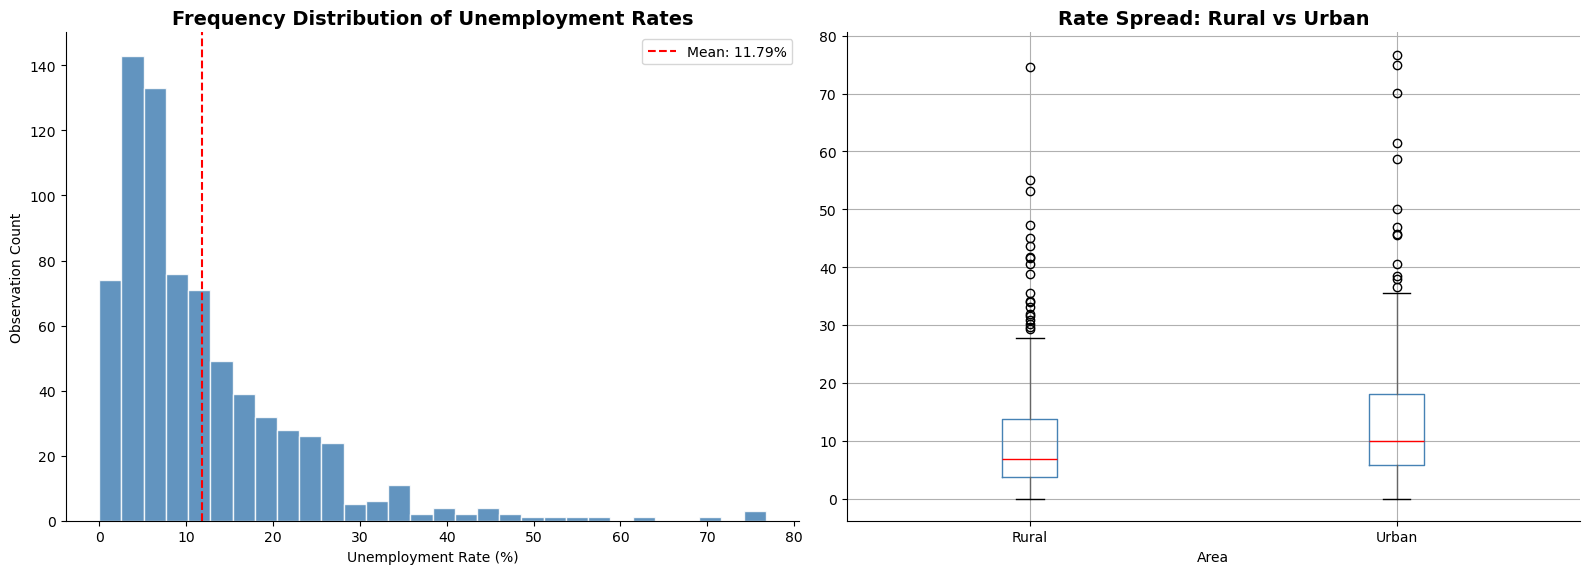

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df['Unemployment_Rate'].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Unemployment_Rate'].mean(), color='red', linestyle='--', label=f"Mean: {df['Unemployment_Rate'].mean():.2f}%")
axes[0].set_title('Frequency Distribution of Unemployment Rates', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Unemployment Rate (%)')
axes[0].set_ylabel('Observation Count')
axes[0].legend()

df.boxplot(column='Unemployment_Rate', by='Area', ax=axes[1], boxprops=dict(color='steelblue'), medianprops=dict(color='red'))
axes[1].set_title('Rate Spread: Rural vs Urban', fontsize=14, fontweight='bold')
plt.suptitle('') 

plt.tight_layout()
plt.show()

### ðŸ“‰ 4.2 Timeline Analysis: Tracking the COVID-19 Surge
We track the monthly trajectory of the unemployment rate to isolate the massive shock introduced by the pandemic lockdown.

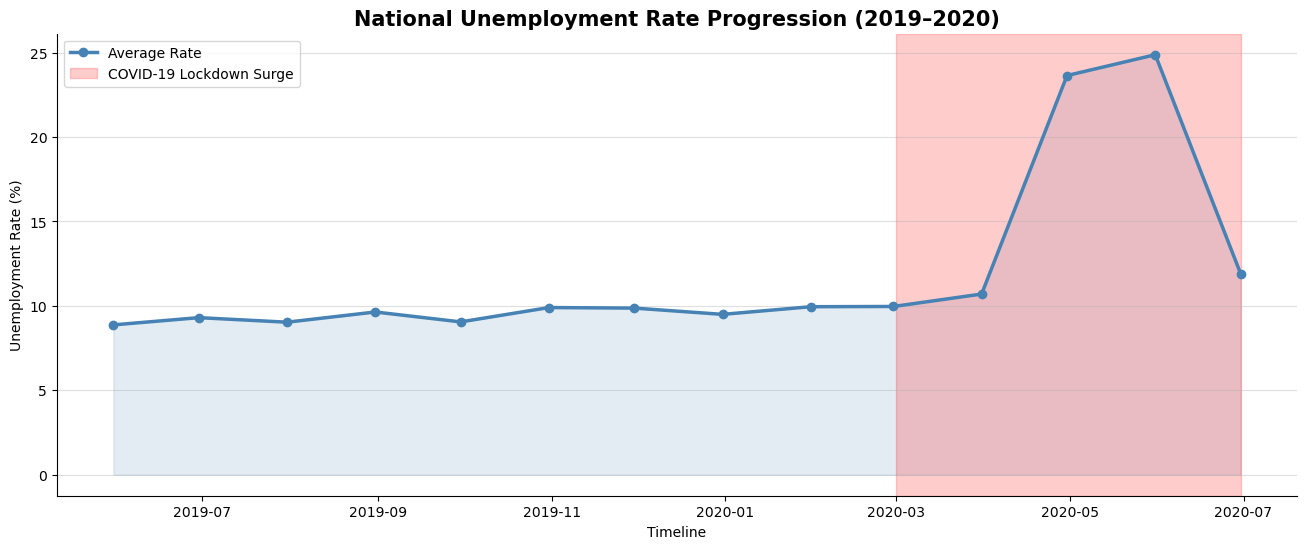

In [7]:
monthly_avg = df.groupby('Date')['Unemployment_Rate'].mean().reset_index()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(monthly_avg['Date'], monthly_avg['Unemployment_Rate'], color='steelblue', linewidth=2.5, marker='o', label='Average Rate')
ax.fill_between(monthly_avg['Date'], monthly_avg['Unemployment_Rate'], alpha=0.15, color='steelblue')

# Highlight the strict Covid Lockdown window in India (March-June 2020)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-30'), alpha=0.2, color='red', label='COVID-19 Lockdown Surge')

ax.set_title('National Unemployment Rate Progression (2019â€“2020)', fontsize=15, fontweight='bold')
ax.set_xlabel('Timeline')
ax.set_ylabel('Unemployment Rate (%)')
ax.grid(axis='y', alpha=0.4)
ax.legend()

plt.show()

### ðŸ—ºï¸ 4.3 State-Wise Breakdown
Visualizing geographical variations. Which states historically struggled the most during this timeframe?

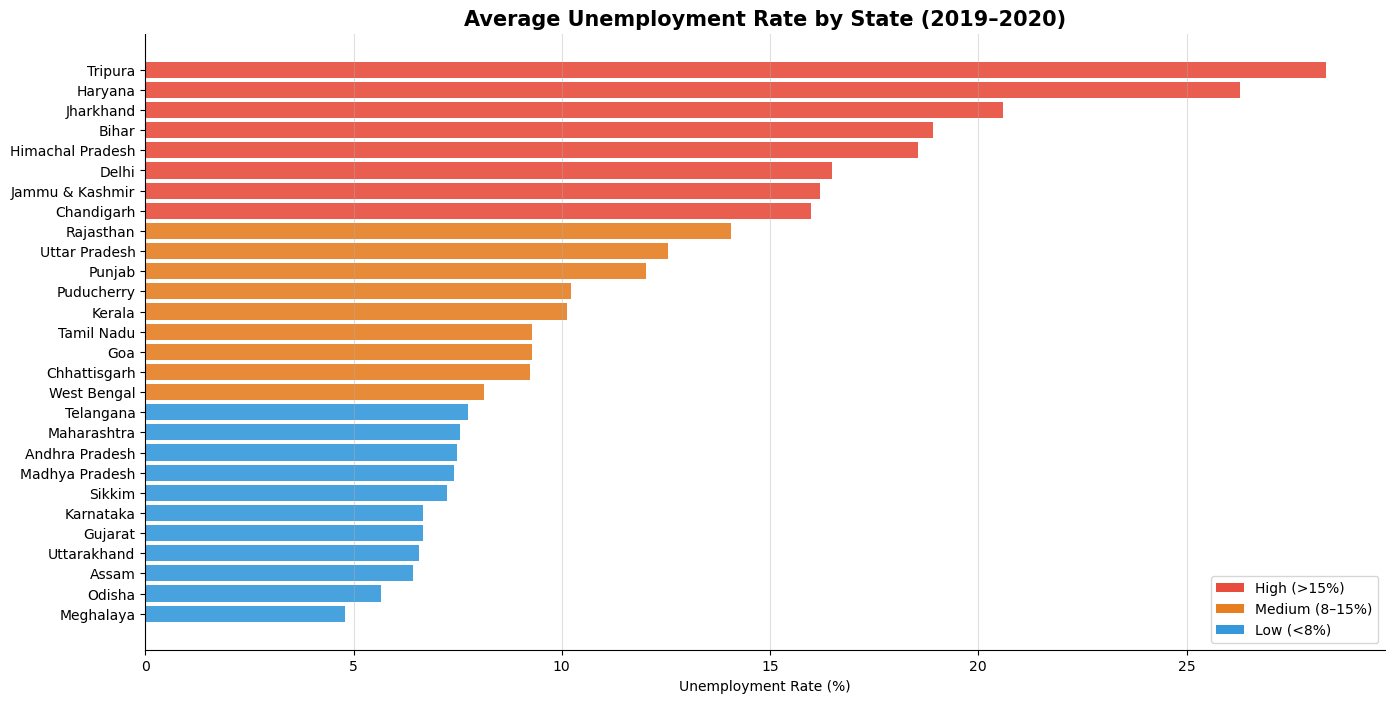

In [8]:
state_avg = df.groupby('State')['Unemployment_Rate'].mean().sort_values(ascending=False)
colors = ['#e74c3c' if v > 15 else '#e67e22' if v > 8 else '#3498db' for v in state_avg.values]

fig, ax = plt.subplots(figsize=(16, 8))
ax.barh(state_avg.index, state_avg.values, color=colors, alpha=0.9)

ax.set_title('Average Unemployment Rate by State (2019â€“2020)', fontsize=15, fontweight='bold')
ax.set_xlabel('Unemployment Rate (%)')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='High (>15%)'),
                   Patch(facecolor='#e67e22', label='Medium (8â€“15%)'),
                   Patch(facecolor='#3498db', label='Low (<8%)')]
ax.legend(handles=legend_elements, loc='lower right')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.4)
plt.show()

### ðŸ™ï¸ 4.4 Pre and Post COVID-19 Paradigm (Rural vs Urban)
Segmenting the temporal data to identify structural weaknesses in urban vs rural labor markets.

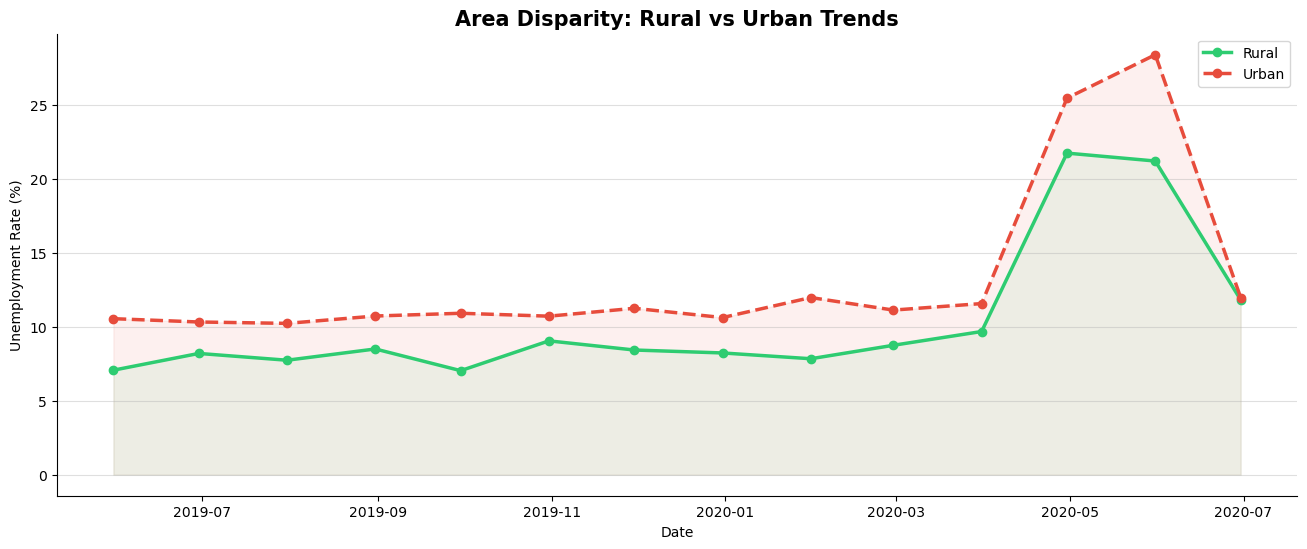

In [9]:
area_trend = df.groupby(['Date', 'Area'])['Unemployment_Rate'].mean().reset_index()

fig, ax = plt.subplots(figsize=(16, 6))

for area, color, ls in [('Rural', '#2ecc71', '-'), ('Urban', '#e74c3c', '--')]:
    subset = area_trend[area_trend['Area'] == area]
    ax.plot(subset['Date'], subset['Unemployment_Rate'], label=area, color=color, linewidth=2.5, linestyle=ls, marker='o')
    ax.fill_between(subset['Date'], subset['Unemployment_Rate'], alpha=0.08, color=color)

ax.set_title('Area Disparity: Rural vs Urban Trends', fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Unemployment Rate (%)')
ax.grid(axis='y', alpha=0.4)
ax.legend()
plt.show()

---
## ðŸš€ Final Deductions & Business Insights

1. **The Lockdown Avalanche:** The nationwide lockdown in late March 2020 resulted in an astronomical leap in the unemployment rate, spiking from an average of ~8% up to a catastrophic `25%+` by April/May.
2. **Urban Suffering:** Urban regions experienced sharper employment declines compared to rural areas. This aligns with the massive stalling of retail, manufacturing, hospitality, and generic service-sector industries heavily stationed in cities.
3. **Geographical Vulnerabilities:** States such as Tripura, Haryana, and Jharkhand demonstrated severe structural flaws in their labor retention, peaking violently compared to southern states which exhibited relatively stronger resilience (Tamil Nadu, Karnataka).
4. **Rebound Phase:** Post-lockdown (June/July 2020 onwards), there was an immediate and aggressive downward curve in the unemployment rate, illustrating a strong market bounce-back once restrictions eased.

---

<div style="text-align: center; font-size: 14px;">
    <b>Developed by: Piyush Ramteke</b><br>
    <i>CodeAlpha Data Science Internship Project</i>
</div>

<div align="center">

<img src="https://capsule-render.vercel.app/api?type=waving&color=0:24243e,50:302b63,100:0f0c29&height=140&section=footer&text=Developed%20by%20Piyush %Ramteke&fontSize=22&fontColor=e0d7ff&fontAlignY=70&fontAlign=50" width="100%"/>
